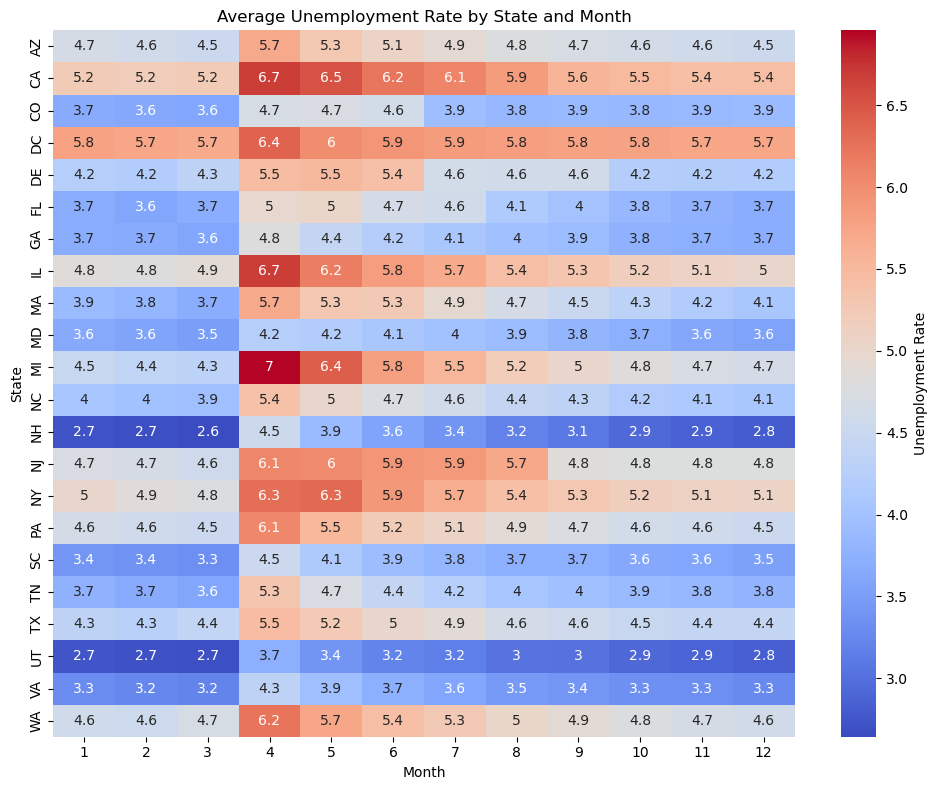

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the data
df = pd.read_csv("../data/raw/Unemployment.csv")

# Step 2: Aggregate to ensure unique (state, month) pairs
df_grouped = df.groupby(["state", "month"], as_index=False)["unemployment_rate"].mean()

# Step 3: Pivot for heatmap
heatmap_data = df_grouped.pivot(index="state", columns="month", values="unemployment_rate")

# Step 4: Plot
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", cbar_kws={'label': 'Unemployment Rate'})
plt.title("Average Unemployment Rate by State and Month")
plt.xlabel("Month")
plt.ylabel("State")
plt.tight_layout()
plt.show()


In [12]:
%pip install "nbformat>=4.2.0"


Note: you may need to restart the kernel to use updated packages.


<Figure size 1400x800 with 0 Axes>

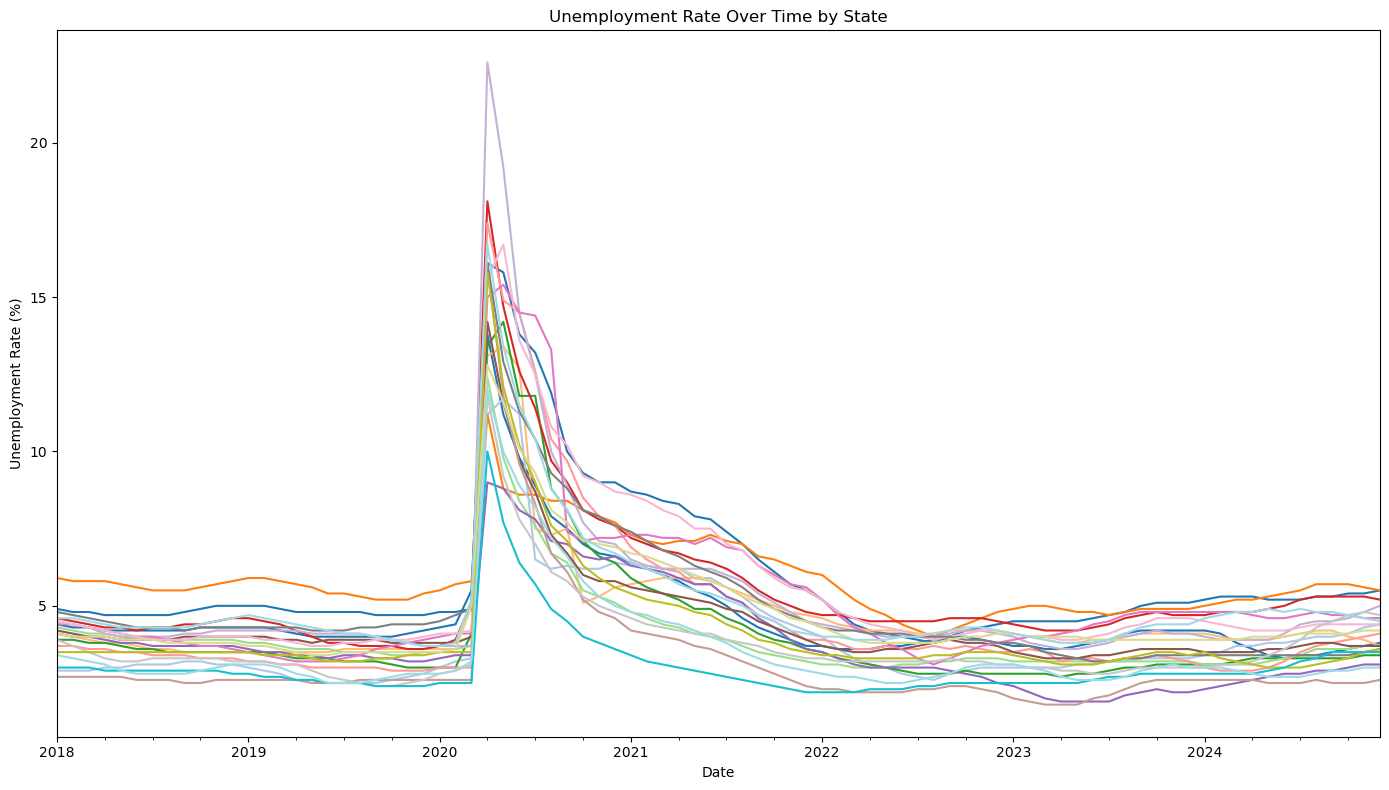

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("../data/raw/Unemployment.csv")

# Combine year and month into a datetime for proper x-axis handling
df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))

# Pivot data to have states as columns and dates as rows
pivot = df.pivot_table(index="date", columns="state", values="unemployment_rate")

# Plotting
plt.figure(figsize=(14, 8))
pivot.plot(figsize=(14, 8), legend=False, colormap="tab20")
plt.title("Unemployment Rate Over Time by State")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()


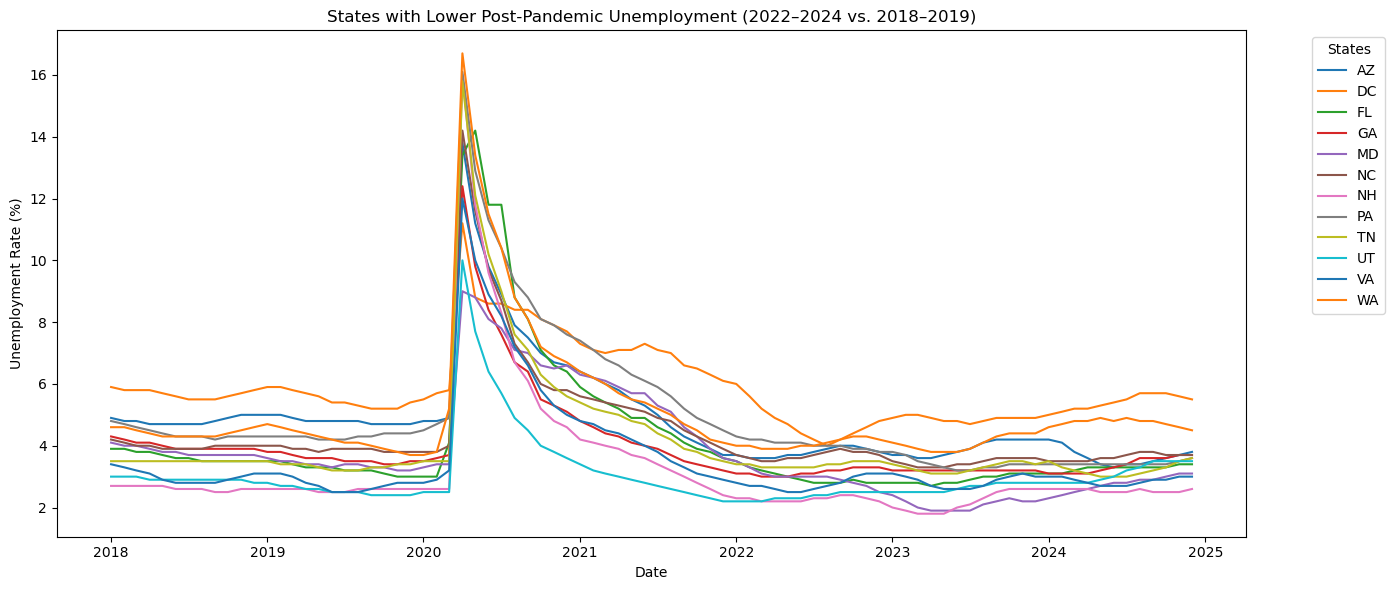

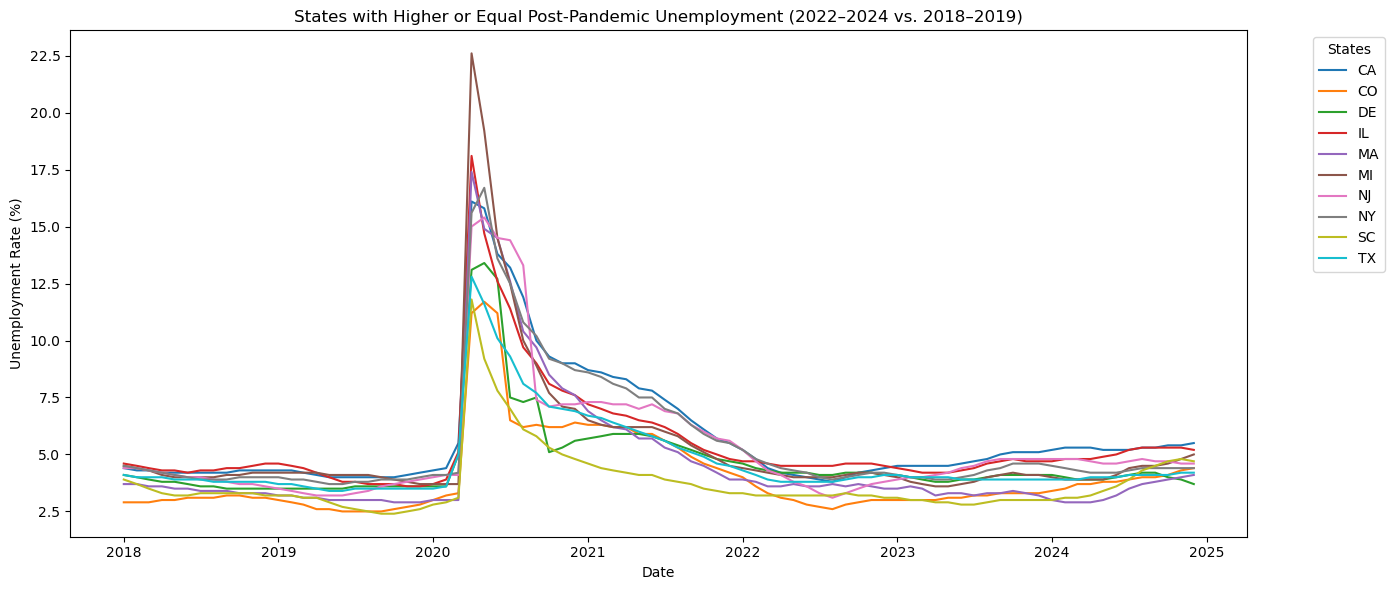

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and preprocess data
df = pd.read_csv("../data/raw/Unemployment.csv")
df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))

# Filter pre-pandemic and post-stabilization data
pre_covid = df[df["year"].isin([2018, 2019])]
post_covid = df[df["year"] >= 2022]

# Compute average unemployment rate per state for both periods
pre_avg = pre_covid.groupby("state")["unemployment_rate"].mean()
post_avg = post_covid.groupby("state")["unemployment_rate"].mean()

# Compare post-pandemic to pre-pandemic
comparison = pd.DataFrame({
    "pre_avg": pre_avg,
    "post_avg": post_avg
})

# Categorize states
lower_states = comparison[comparison["post_avg"] < comparison["pre_avg"]].index.tolist()
higher_states = comparison[comparison["post_avg"] >= comparison["pre_avg"]].index.tolist()

# Pivot full data for plotting
df_pivot = df.pivot_table(index="date", columns="state", values="unemployment_rate")

# Plot states with lower post-pandemic unemployment
plt.figure(figsize=(14, 6))
for state in lower_states:
    plt.plot(df_pivot.index, df_pivot[state], label=state)
plt.title("States with Lower Post-Pandemic Unemployment (2022–2024 vs. 2018–2019)")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Date")
plt.legend(title="States", bbox_to_anchor=(1.05, 1), loc='upper left')  # Place the legend outside the plot
plt.tight_layout()
plt.show()

# Plot states with higher post-pandemic unemployment
plt.figure(figsize=(14, 6))
for state in higher_states:
    plt.plot(df_pivot.index, df_pivot[state], label=state)
plt.title("States with Higher or Equal Post-Pandemic Unemployment (2022–2024 vs. 2018–2019)")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Date")
plt.legend(title="States", bbox_to_anchor=(1.05, 1), loc='upper left')  # Place the legend outside the plot
plt.tight_layout()
plt.show()


In [8]:
import plotly.express as px
import pandas as pd

df = pd.read_csv("../data/raw/Unemployment.csv")
num_states = df["state"].nunique()
print(f"Number of unique states: {num_states}")

# Create a formatted string for animation
df["time"] = df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2)

fig = px.choropleth(
    df,
    locations="state",
    locationmode="USA-states",
    color="unemployment_rate",
    animation_frame="time",
    scope="usa",
    color_continuous_scale="Reds",
    labels={"unemployment_rate": "Unemployment Rate"},
    title="Monthly Unemployment Rate by State (2018–2024)"
)

fig.show()


Number of unique states: 22
